# Wine Classifier with KNN Using `quality` Directly

Train a **K-Nearest Neighbors (KNN)** model to predict the **original wine quality score** of red wine based on its chemical properties.

In this version of the notebook, we use the raw target column **`quality`** directly instead of creating a grouped column like `label`.

That means:
- the model predicts the original quality values from the dataset,
- this becomes a **multiclass classification** problem,
- the possible classes are the wine quality scores already present in the data.

## Steps

### 1. Load the data
Load the CSV with Pandas and explore its structure.

### 2. Train the KNN model
- Separate the independent variables (**X**) from the target (**y**).
- Split into training and testing sets (**80 20**).
- Scale the data if necessary (**highly recommended with KNN**).
- Train the model with an initial **k** value.

### 3. Evaluate performance
Use:
- `accuracy_score`
- `confusion_matrix`
- `classification_report`

### 4. Optimize `k`
- Try several values of `k` from 1 to 20.
- Save the results in a list.
- Plot accuracy vs `k`.

### 5. Create a prediction function
Create a function that receives 11 chemical values and predicts the wine quality score.

### 6. Save the model
Save the final KNN model and the scaler.


## 1. Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2. Load the dataset

The attached CSV uses a semicolon `;` as separator, so we must specify `sep=";"` when reading it.

In this version, we will use the original target column `quality` directly.


In [3]:
file_path = "../data/raw/winequality-red.csv"

# the file uses semicolons instead of commas
df = pd.read_csv(file_path, sep=";")

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Explore the structure of the data

Now the dataset keeps the original target column `quality`, which we will use directly.


In [4]:
print("Shape of the dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget values:")
print(df["quality"].value_counts().sort_index())


Shape of the dataset:
(1599, 12)

Column names:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality        

## 4. Separate X and y

- `X` contains the predictor variables.
- We remove only `quality` from `X`.
- `y` contains the target column `quality`.


In [5]:
X = df.drop("quality", axis=1)
y = df["quality"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature names:")
print(X.columns.tolist())


X shape: (1599, 11)
y shape: (1599,)

Feature names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 5. Split the data into training and testing sets

We will use:
- 80 percent for training
- 20 percent for testing


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1279, 11)
X_test shape: (320, 11)
y_train shape: (1279,)
y_test shape: (320,)


## 6. Scale the data

KNN works with distances, so scaling is very important.
We use `StandardScaler` so that all variables are on a similar scale.


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)


Scaled training data shape: (1279, 11)
Scaled test data shape: (320, 11)


## 7. Train a first KNN model

We start with a simple value: `k = 5`.


In [8]:
k = 5

knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)


## 8. Evaluate the first model

In [9]:
first_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy with k = 5:", first_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy with k = 5: 0.609375

Confusion Matrix:
[[ 0  0  0  2  0  0]
 [ 0  0  7  4  0  0]
 [ 0  1 92 41  2  0]
 [ 0  1 38 80  9  0]
 [ 0  0  4 13 23  0]
 [ 0  0  0  1  2  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.65      0.68      0.66       136
           6       0.57      0.62      0.59       128
           7       0.64      0.57      0.61        40
           8       0.00      0.00      0.00         3

    accuracy                           0.61       320
   macro avg       0.31      0.31      0.31       320
weighted avg       0.58      0.61      0.60       320



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 9. Try different values of k

Now we test values from **1 to 20** and save the accuracy for each one.


In [10]:
k_values = []
accuracy_values = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_pred_k = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)

    k_values.append(k)
    accuracy_values.append(acc)

results_df = pd.DataFrame({
    "k": k_values,
    "accuracy": accuracy_values
})

results_df


,k,accuracy
0,1,0.625000
1,2,0.587500
2,3,0.575000
3,4,0.581250
4,5,0.609375
5,6,0.593750
6,7,0.593750
7,8,0.590625
8,9,0.600000
9,10,0.596875


## 10. Find the best k

In [11]:
best_index = results_df["accuracy"].idxmax()
best_k = results_df.loc[best_index, "k"]
best_accuracy = results_df.loc[best_index, "accuracy"]

print("Best k:", best_k)
print("Best accuracy:", best_accuracy)


Best k: 1
Best accuracy: 0.625


## 11. Plot accuracy vs k

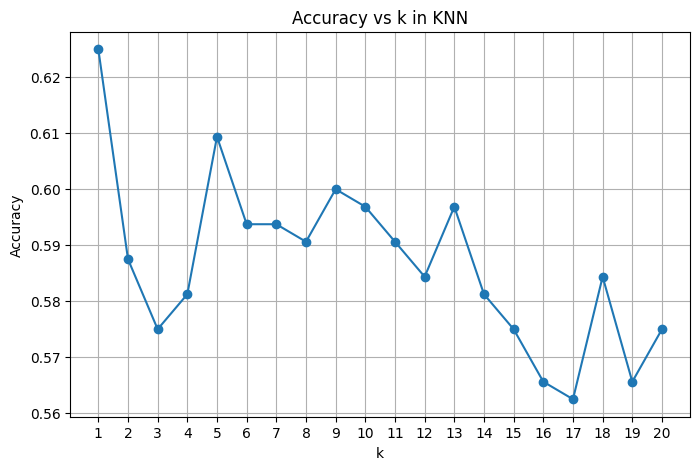

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_values, marker="o")
plt.title("Accuracy vs k in KNN")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()


## 12. Train the final model with the best k

In [13]:
final_knn_model = KNeighborsClassifier(n_neighbors=int(best_k))
final_knn_model.fit(X_train_scaled, y_train)

final_predictions = final_knn_model.predict(X_test_scaled)

print("Final model accuracy:", accuracy_score(y_test, final_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))


Final model accuracy: 0.625

Confusion Matrix:
[[ 0  1  0  1  0  0]
 [ 0  2  4  5  0  0]
 [ 0  5 90 31  9  1]
 [ 0  5 23 84 14  2]
 [ 0  1  4 10 23  2]
 [ 0  0  1  0  1  1]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.14      0.18      0.16        11
           5       0.74      0.66      0.70       136
           6       0.64      0.66      0.65       128
           7       0.49      0.57      0.53        40
           8       0.17      0.33      0.22         3

    accuracy                           0.62       320
   macro avg       0.36      0.40      0.38       320
weighted avg       0.64      0.62      0.63       320



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 13. Create a prediction function

This function:
1. receives the 11 chemical values,
2. scales them with the same scaler,
3. predicts the wine quality score,
4. returns an easy-to-read sentence.


In [14]:
def predict_wine_quality(wine_values):
    # convert the input into a DataFrame with the same column names
    wine_df = pd.DataFrame([wine_values], columns=X.columns)

    # scale the values
    wine_scaled = scaler.transform(wine_df)

    # predict the quality score
    prediction = final_knn_model.predict(wine_scaled)[0]

    return f"This wine is likely to have quality score {prediction} 🍷"


## 14. Test the prediction function

In [15]:
sample_wine = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]

predict_wine_quality(sample_wine)


'This wine is likely to have quality score 5 🍷'

## 15. Save the final model

We save:
- the final KNN model
- the scaler

This is useful because KNN needs the same scaling process when making future predictions.


In [16]:
joblib.dump(final_knn_model, "knn_wine_quality_direct_model.pkl")
joblib.dump(scaler, "knn_wine_quality_direct_scaler.pkl")

print("Model and scaler saved successfully.")


Model and scaler saved successfully.


## 16. Conclusion

- We loaded the wine dataset correctly using `sep=";"`.
- We used the original target column `quality` directly.
- We separated predictors and target.
- We split the data into training and test sets.
- We scaled the variables because KNN depends on distances.
- We trained a first KNN model.
- We tested several values of `k`.
- We selected the best `k` based on accuracy.
- We created a function to predict the wine quality score from new chemical values.
- We saved the final model and the scaler.

This is a complete junior-level KNN workflow for a multiclass classification problem using the original wine quality scores.
